# In Silico `Toxicity` prediction for `Ebola` AntiViral Candidates

This notebook implements a statistically grounded, **FDA-approved-AntiViral-reference-driven** workflow for ranking generated AntiViral candidates using:

- **pPotency (pIC50)** (higher is better)
- **Toxicity burden** (lower is better)
- **ADME feasibility** (higher is better)

The design follows three core ideas from the literature:

1. **QED-style desirability scoring**  
   Heterogeneous properties should first be mapped to a common 0–1 desirability scale and then combined continuously rather than by rigid pass/fail rules.

2. **ADMET-score-style weighted aggregation**  
   ADMET endpoints should not all contribute equally. More informative and clinically important endpoints should get stronger weight.

3. **ADMET-AI reference-based interpretation**  
   ADMET properties are most meaningful when interpreted relative to an appropriate approved-drug reference set.  
   For this project, the most relevant reference set is **FDA-approved AntiVirals**.

The goal is to support **early prioritization**, not to make definitive toxicity claims.

## What this notebook does

1. Harmonizes the reference and candidate dataframes
2. Keeps only metadata, potency, toxicity, ADME, and useful physicochemical columns
3. Splits `ADMET-AI` outputs into **Toxicity** and **ADME**
4. Derives **AntiViral-reference-driven statistical weights**
5. Converts each endpoint into a **desirability score**
6. Builds:
   - `ToxicitySafety`
   - `Toxicity Score = 1 - ToxicitySafety`
   - `ADMEFeasibility`
7. Generates:
   - 2D plot: pPotency vs Toxicity burden
   - 3D plot: pPotency vs Toxicity burden vs ADME feasibility
   - Save top-20 candidates to CSV files

In [3]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy.stats import percentileofscore

## Define data directory for model trained on `ChEMBL + PubChem` bioassay dataset

In [4]:
target_organism = "combinedEbolaVirus"

In [5]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
saveDir = os.path.join(dataDir, f"Results/{target_organism}_bestMACAW_allDB/")
os.makedirs(saveDir, exist_ok=True)

### Read `ADMET` endpoints with `pPotency`of the FDA approved Drug data from `Drugbank`

In [13]:
drugBankDrug_FDAapproved_AntiViral_wART = pd.read_csv(saveDir + f'{target_organism}Data_FDA_approved_Antivirals_ARTprediction.csv')
# Identify columns that match the string
matched_cols = drugBankDrug_FDAapproved_AntiViral_wART.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
drugBankDrug_FDAapproved_AntiViral_wART = drugBankDrug_FDAapproved_AntiViral_wART.drop(columns=matched_cols)
max_val = drugBankDrug_FDAapproved_AntiViral_wART['pPotency_prediction'].max()
min_val = drugBankDrug_FDAapproved_AntiViral_wART['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
drugBankDrug_FDAapproved_AntiViral_wART

pPotency_prediction range: 4.852 → 5.879


,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,0.000067
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,0.000106
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,0.000068
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,5.175844,0.542325,4.112886,6.238802,0.000007,5.770297e-07,0.000077
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,5.626048,0.541898,4.563928,6.688167,0.000002,2.050374e-07,0.000027
...,...,...,...,...,...,...,...,...
70,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,5.536453,0.540180,4.477700,6.595206,0.000003,2.539768e-07,0.000033
71,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,5.878781,0.543114,4.814277,6.943285,0.000001,1.139502e-07,0.000015
72,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,5.039875,0.540991,3.979532,6.100217,0.000009,7.939315e-07,0.000105
73,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,5.297290,0.545680,4.227758,6.366822,0.000005,4.297122e-07,0.000059


In [28]:
drugBankDrug_FDAapproved_AntiViral_wToxicity = pd.read_csv(dataDir + '/Toxicity/DrugBank/drugBankDrug_FDAapproved_antiviral_wToxicity.csv')
drugBankDrug_FDAapproved_AntiViral_wToxicity["source_DataBase"] = "FDA_Antivirals"
drugBankDrug_FDAapproved_AntiViral_wToxicity

,Unnamed: 0,smiles,ATC_code,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,...,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile,source_DataBase
0,0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,286.339,1.09230,7,3,4.0,0.727230,...,14.928267,11.942613,38.891043,12.407910,40.674680,56.029469,33.385033,62.582396,36.719659,FDA_Antivirals
1,1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,225.208,-1.33180,7,3,4.0,0.554386,...,37.495153,7.289647,10.779372,2.210159,17.409849,13.067080,12.679333,70.337340,68.476154,FDA_Antivirals
2,2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,501.477,2.70250,13,1,2.0,0.207152,...,91.818534,96.936797,17.138426,57.658007,27.025979,62.000775,43.544009,51.298953,49.670415,FDA_Antivirals
3,3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,505.637,2.40280,7,3,3.0,0.399740,...,84.722761,96.316402,23.652579,45.637844,82.667701,75.843350,59.790617,21.558744,71.733230,FDA_Antivirals
4,4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,748.299,3.85380,10,3,3.0,0.285739,...,34.082978,83.753393,65.878247,44.241954,98.953083,77.975960,79.526948,10.120202,57.153936,FDA_Antivirals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,72,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,J05AB,antiviral,267.245,-1.98000,9,4,4.0,0.490520,...,21.054672,28.460644,47.227608,1.318340,25.009694,13.454827,7.367197,78.673905,13.144630,FDA_Antivirals
73,73,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,J05AP,antiviral,868.948,4.95650,11,3,2.0,0.303895,...,54.168282,96.200078,60.178364,62.504847,99.612253,80.302443,89.957348,2.248934,87.902288,FDA_Antivirals
74,74,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,J05AF,antiviral,211.221,-0.50460,6,2,4.0,0.687546,...,37.844126,9.616130,49.864288,3.916247,25.785188,12.601784,6.397829,87.708414,48.623497,FDA_Antivirals
75,75,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,J05AH,antiviral,332.313,-3.78550,7,7,3.0,0.188042,...,3.955021,6.824351,17.797596,1.861187,10.314075,0.504071,3.140752,88.716557,84.257464,FDA_Antivirals


In [29]:
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

# Canonicalize SMILES in both DataFrames
drugBankDrug_FDAapproved_AntiViral_wART["canon_SMILES"] = \
    drugBankDrug_FDAapproved_AntiViral_wART["smiles"].apply(canonicalize)

drugBankDrug_FDAapproved_AntiViral_wToxicity["canon_SMILES"] = \
    drugBankDrug_FDAapproved_AntiViral_wToxicity["smiles"].apply(canonicalize)

# Merge on canonical SMILES
drugBankDrug_FDAapproved_AntiViral_wART_wADMET = pd.merge(
    drugBankDrug_FDAapproved_AntiViral_wART,
    drugBankDrug_FDAapproved_AntiViral_wToxicity.drop(columns="smiles"),  
    on="canon_SMILES",
    how="inner"
).drop(columns="canon_SMILES").reset_index(drop=True)

print(f"wART shape        : {drugBankDrug_FDAapproved_AntiViral_wART.shape}")
print(f"wToxicity shape   : {drugBankDrug_FDAapproved_AntiViral_wToxicity.shape}")
print(f"Merged shape      : {drugBankDrug_FDAapproved_AntiViral_wART_wADMET.shape}")

wART shape        : (75, 9)
wToxicity shape   : (77, 104)
Merged shape      : (75, 110)


### Convert `SMILES` to `Canonical SMILES` for comparison

In [30]:
def canonicalizeSmiles(smilesValue):
    if pd.isna(smilesValue):
        return None

    smilesStr = str(smilesValue).strip()
    if smilesStr == "":
        return None

    mol = Chem.MolFromSmiles(smilesStr)
    if mol is None:
        return None

    return Chem.MolToSmiles(mol, canonical=True)

drugBankDrug_FDAapproved_AntiViral_wART_wADMET = drugBankDrug_FDAapproved_AntiViral_wART_wADMET.copy()
drugBankDrug_FDAapproved_AntiViral_wART_wADMET["smiles"] = (
    drugBankDrug_FDAapproved_AntiViral_wART_wADMET["smiles"].apply(canonicalizeSmiles)
)

drugBankDrug_FDAapproved_AntiViral_wART_wADMET

,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile,source_DataBase
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,0.000067,0,J05AF;J05AR,...,14.928267,11.942613,38.891043,12.407910,40.674680,56.029469,33.385033,62.582396,36.719659,FDA_Antivirals
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,0.000106,1,J05AB,...,37.495153,7.289647,10.779372,2.210159,17.409849,13.067080,12.679333,70.337340,68.476154,FDA_Antivirals
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,0.000068,2,J05AF,...,91.818534,96.936797,17.138426,57.658007,27.025979,62.000775,43.544009,51.298953,49.670415,FDA_Antivirals
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,5.175844,0.542325,4.112886,6.238802,0.000007,5.770297e-07,0.000077,3,J05AE,...,84.722761,96.316402,23.652579,45.637844,82.667701,75.843350,59.790617,21.558744,71.733230,FDA_Antivirals
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,5.626048,0.541898,4.563928,6.688167,0.000002,2.050374e-07,0.000027,4,J05AP,...,34.082978,83.753393,65.878247,44.241954,98.953083,77.975960,79.526948,10.120202,57.153936,FDA_Antivirals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,5.536453,0.540180,4.477700,6.595206,0.000003,2.539768e-07,0.000033,72,J05AB,...,21.054672,28.460644,47.227608,1.318340,25.009694,13.454827,7.367197,78.673905,13.144630,FDA_Antivirals
71,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,5.878781,0.543114,4.814277,6.943285,0.000001,1.139502e-07,0.000015,73,J05AP,...,54.168282,96.200078,60.178364,62.504847,99.612253,80.302443,89.957348,2.248934,87.902288,FDA_Antivirals
72,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,5.039875,0.540991,3.979532,6.100217,0.000009,7.939315e-07,0.000105,74,J05AF,...,37.844126,9.616130,49.864288,3.916247,25.785188,12.601784,6.397829,87.708414,48.623497,FDA_Antivirals
73,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,5.297290,0.545680,4.227758,6.366822,0.000005,4.297122e-07,0.000059,75,J05AH,...,3.955021,6.824351,17.797596,1.861187,10.314075,0.504071,3.140752,88.716557,84.257464,FDA_Antivirals


### Retain only `toxicity`, `mechanistic`, and `ADME` related endpoints

In [31]:
# Potency-related columns
dataCols = [
    "smiles",
    "ATC_code", "Drug_Type", "source_DataBase"
]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_AntiViral_wART_wADMET.columns
]

drugBankDrug_FDAapproved_AntiViral_wART_wADMET = drugBankDrug_FDAapproved_AntiViral_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_AntiViral_wART_wADMET.shape)
drugBankDrug_FDAapproved_AntiViral_wART_wADMET.head()

Filtered dataframe shape: (75, 44)


,smiles,ATC_code,Drug_Type,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,FDA_Antivirals,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,...,0.682142,0.900314,0.452779,0.051874,0.091861,0.045425,0.090017,0.021314,0.279831,0.205709
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,FDA_Antivirals,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,...,0.024756,0.576378,0.003340,0.000488,0.049340,0.001506,0.021066,0.000547,0.052355,0.000207
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,FDA_Antivirals,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,...,0.950870,0.675607,0.003372,0.131225,0.038136,0.208273,0.030708,0.023926,0.875641,0.698997
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,FDA_Antivirals,5.175844,0.542325,4.112886,6.238802,0.000007,5.770297e-07,...,0.789846,0.558204,0.087809,0.779787,0.377403,0.749684,0.240774,0.437612,0.715497,0.982761
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,FDA_Antivirals,5.626048,0.541898,4.563928,6.688167,0.000002,2.050374e-07,...,0.946405,0.847933,0.093194,0.616985,0.333340,0.768412,0.095483,0.129816,0.905202,0.989531


# Check ADMET properties for `buyable` AntiVirals

### 1. Read `ART` predicted `pPotency` of all the compounds

In [32]:
Ebola_wART_Buyable_predicted_all = pd.read_csv(saveDir + f'{target_organism}_all_Buyable_AntiVirals_ARTprediction.csv')
max_val = Ebola_wART_Buyable_predicted_all['pPotency_prediction'].max()
min_val = Ebola_wART_Buyable_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_wART_Buyable_predicted_all

pPotency_prediction range: 4.615 → 6.410


,SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,Enamine_Antivirals,5.105670,0.545426,4.036636,6.174704,0.000008,6.687996e-07,0.000092
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,Enamine_Antivirals,5.007438,0.547443,3.934450,6.080427,0.000010,8.309468e-07,0.000116
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,Enamine_Antivirals,4.819532,0.541383,3.758420,5.880643,0.000015,1.316305e-06,0.000174
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,Enamine_Antivirals,5.087139,0.546747,4.015516,6.158762,0.000008,6.938054e-07,0.000096
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,Enamine_Antivirals,5.392557,0.543045,4.328189,6.456925,0.000004,3.492006e-07,0.000047
...,...,...,...,...,...,...,...,...,...
113180,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,ChemDiv_Antivirals,5.484249,0.540973,4.423942,6.544555,0.000003,2.853942e-07,0.000038
113181,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,ChemDiv_Antivirals,5.403186,0.539742,4.345291,6.461081,0.000004,3.458748e-07,0.000045
113182,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,ChemDiv_Antivirals,5.406166,0.541336,4.345146,6.467185,0.000004,3.410477e-07,0.000045
113183,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,ChemDiv_Antivirals,5.376473,0.541037,4.316041,6.436905,0.000004,3.656748e-07,0.000048


### plot `pPotency` distribution with error bars

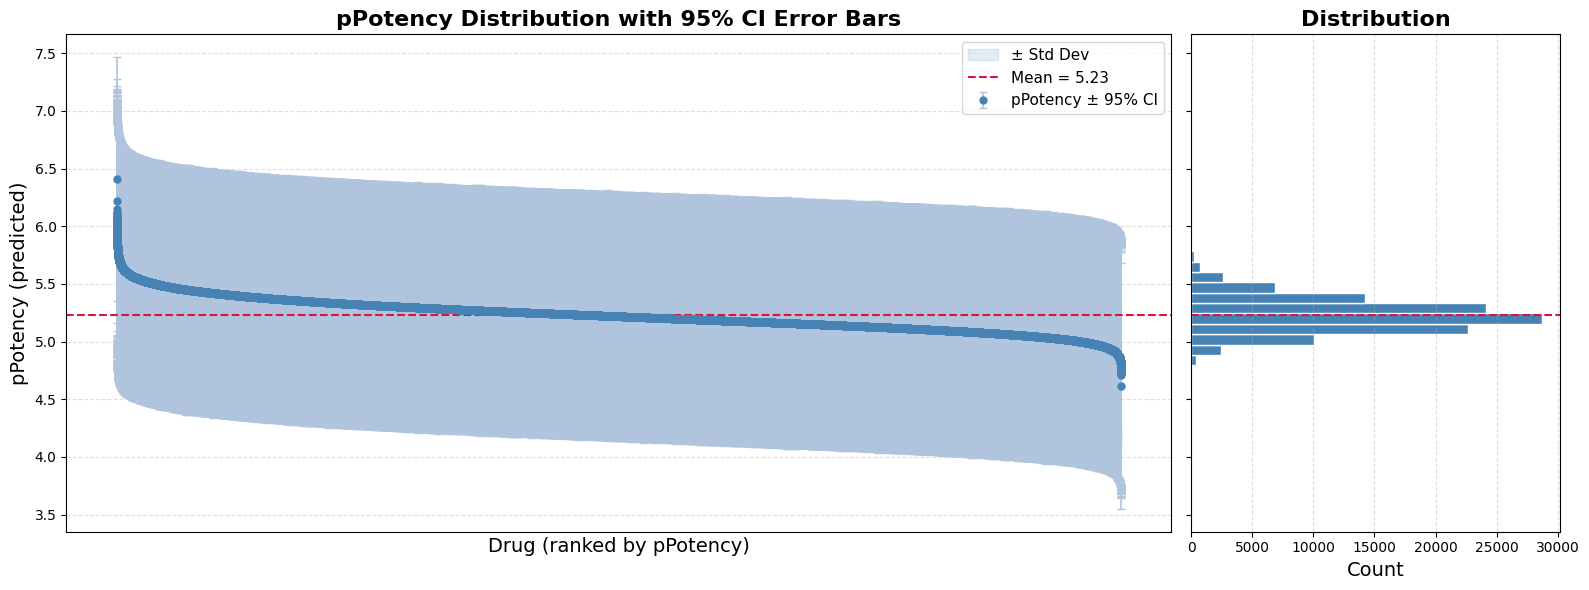

In [33]:
ppotencyDF = Ebola_wART_Buyable_predicted_all.sort_values(
    "pPotency_prediction", ascending=False).reset_index(drop=True)

x = np.arange(len(ppotencyDF))
pred = ppotencyDF["pPotency_prediction"]
yerr = np.array([pred - ppotencyDF["pPotency_lower_95CI"],
                 ppotencyDF["pPotency_upper_95CI"] - pred])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

# ── Scatter + error bars ──────────────────────────────────────────────────────
ax1.errorbar(x, pred, yerr=yerr, fmt='o', color='steelblue', ecolor='lightsteelblue',
             elinewidth=1.2, capsize=3, markersize=5, alpha=1, label="pPotency ± 95% CI")
ax1.fill_between(x, pred - ppotencyDF["pPotency_std"], pred + ppotencyDF["pPotency_std"],
                 alpha=0.15, color='steelblue', label="± Std Dev")
ax1.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {pred.mean():.2f}')
#ax1.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {pred.median():.2f}')
ax1.set_xlabel("Drug (ranked by pPotency)", fontsize=14)  
ax1.set_ylabel("pPotency (predicted)",      fontsize=14) 
ax1.set_title("pPotency Distribution with 95% CI Error Bars", fontsize=16, fontweight='bold')  
ax1.set_xticks([])
ax1.legend(fontsize=11); ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Histogram ─────────────────────────────────────────────────────────────────
ax2.hist(pred, bins=20, orientation='horizontal', color='steelblue', edgecolor='white', alpha=1)
ax2.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5)
#ax2.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5)
ax2.set_xlabel("Count", fontsize=14)        
ax2.set_title("Distribution", fontsize=16, fontweight='bold') 
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_buyable.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Read predicted `ADMET` properties for all candidate SMILES

In [34]:
Ebola_wART_BuyableDataset_predicted_all_wToxicity = pd.read_csv(saveDir + f'{target_organism}_all_Buyable_AntiVirals_ARTprediction_wToxicity.csv')
# Identify columns that match the string
matched_cols = Ebola_wART_BuyableDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
Ebola_wART_BuyableDataset_predicted_all_wToxicity = Ebola_wART_BuyableDataset_predicted_all_wToxicity.drop(columns=matched_cols)
max_val = Ebola_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = Ebola_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_wART_BuyableDataset_predicted_all_wToxicity

pPotency_prediction range: 4.615 → 6.410


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,5.105670,0.545426,4.036636,6.174704,0.000008,6.687996e-07,0.000092,256.331,1.57190,...,-4.387420,64.435593,40.445525,-0.887841,-12.251157,2.346986,1.866958,63.776392,-2.795747,-2.227612
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,5.007438,0.547443,3.934450,6.080427,0.000010,8.309468e-07,0.000116,237.259,-0.92680,...,-4.118667,36.395596,10.623648,5.505255,-15.261978,2.588685,-0.504724,40.281371,-0.807687,-1.102727
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.819532,0.541383,3.758420,5.880643,0.000015,1.316305e-06,0.000174,306.410,0.98980,...,-4.513040,43.755997,-2.262052,28.229884,-13.875501,2.486431,-0.378004,13.197555,-0.554629,12.543866
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,5.087139,0.546747,4.015516,6.158762,0.000008,6.938054e-07,0.000096,279.384,1.82454,...,-4.838942,26.530763,-0.233076,6.638393,-11.161636,2.715900,-0.066394,26.616980,-0.733000,2.773648
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,5.392557,0.543045,4.328189,6.456925,0.000004,3.492006e-07,0.000047,307.394,0.46540,...,-4.732135,59.017449,-6.087209,11.271385,-13.392374,2.247248,-0.336078,20.670329,-0.587551,4.776085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62704,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(OC)cc4)cc(C(F...,5.394282,0.540136,4.335616,6.452948,0.000004,3.524128e-07,0.000046,518.517,5.53104,...,-4.730722,80.398760,114.804424,120.250929,-9.220663,3.371748,3.856508,98.441311,-5.570580,0.703579
62705,COC(=O)c1ccc(C(=O)OC)c(NC(=O)c2cc3nc(-c4ccc(Cl...,5.337847,0.539813,4.279814,6.395881,0.000005,4.019010e-07,0.000053,532.862,4.89400,...,-4.707452,60.007165,94.408947,136.472807,-10.000819,2.649364,3.893967,96.525146,-6.358163,-1.840952
62706,O=C(Nc1cccc2c1OCO2)c1nn2c(C(F)(F)F)cc(-c3ccc(B...,5.310343,0.540605,4.250758,6.369928,0.000005,4.266506e-07,0.000056,539.695,5.81200,...,-4.720724,49.311068,61.478602,113.462363,-9.338126,3.658687,3.878444,98.976398,-7.572840,-1.263532
62707,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.595679,0.541848,4.533656,6.657701,0.000003,2.199372e-07,0.000029,555.003,6.35520,...,-4.633107,59.457291,97.702937,107.697867,-8.234177,3.655312,3.864897,99.018482,-6.029606,4.871039


### 2. AntiViral candidate prioritization by comparing with `Drugbank`

In [35]:
refDrugbankDF = drugBankDrug_FDAapproved_AntiViral_wART_wADMET.copy()
generatedCandidateDF = Ebola_wART_BuyableDataset_predicted_all_wToxicity.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)

Drugbank reference dataframe shape: (75, 44)
Generated candidate dataframe shape: (62709, 57)


### 3. Harmonize metadata and the SMILES column

The candidate dataframe may use `SMILES` instead of `smiles`.  
This cell standardizes that and fills a few metadata fields if they are missing.

In [36]:
if "SMILES" in generatedCandidateDF.columns:
    generatedCandidateDF = generatedCandidateDF.rename(columns={"SMILES": "smiles"})

if "ATC_code" not in generatedCandidateDF.columns:
    generatedCandidateDF["ATC_code"] = pd.NA

if "Drug_Type" not in generatedCandidateDF.columns:
    generatedCandidateDF["Drug_Type"] = "Predicted_candidate"

if "source_DataBase" not in generatedCandidateDF.columns:
    generatedCandidateDF["source_DataBase"] = "Generated"

refDrugbankDF["datasetLabel"] = "FDA-approved AntiVirals"
generatedCandidateDF["datasetLabel"] = "Generated candidates"

print("smiles in refDrugbankDF:", "smiles" in refDrugbankDF.columns)
print("smiles in generatedCandidateDF:", "smiles" in generatedCandidateDF.columns)

smiles in refDrugbankDF: True
smiles in generatedCandidateDF: True


### 4. Define `ADMET` column groups

We keep:
- metadata
- potency-related columns
- toxicity-related columns
- ADME-related columns
- a few physicochemical property columns such as `QED`, `logP` and `molecular_weight`

In [37]:
metadataCols = [
    "smiles",
    "ATC_code",
    "Drug_Type",
    "source_DataBase",
    "datasetLabel",
]

potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "IC50(M)_prediction",
    "IC50(M)_lower_95CI",
    "IC50(M)_upper_95CI",
]

toxicityCols = [
    "AMES",
    "Carcinogens_Lagunin",
    "ClinTox",
    "DILI",
    "Skin_Reaction",
    "hERG",
    "LD50_Zhu",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]

admeCols = [
    "Bioavailability_Ma",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Caco2_Wang",
    "Solubility_AqSolDB",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
    "Pgp_Broccatelli",
    "Clearance_Hepatocyte_AZ",
    "Clearance_Microsome_AZ",
    "Half_Life_Obach",
    "PPBR_AZ",
    "VDss_Lombardo",
]

optionalCols = ["BBB_Martins"]

physicochemCols = [
    "molecular_weight",
    "logP",
    "hydrogen_bond_acceptors",
    "hydrogen_bond_donors",
    "Lipinski",
    "QED",
    "stereo_centers",
    "tpsa",
    "HydrationFreeEnergy_FreeSolv",
    "Lipophilicity_AstraZeneca",
]

keepCols = list(dict.fromkeys(metadataCols + potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))
print("Total kept columns:", len(keepCols))

Total kept columns: 61


### 5. Build aligned reference and candidate dataframes

This cell keeps the same columns in both dataframes and creates any missing columns as `NaN`

In [38]:
def ensureCols(DF, colList):
    outDF = DF.copy()
    for colName in colList:
        if colName not in outDF.columns:
            outDF[colName] = np.nan
    return outDF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)

print("Reference aligned shape:", refScoreDF.shape)
print("Candidate aligned shape:", candScoreDF.shape)

Reference aligned shape: (75, 61)
Candidate aligned shape: (62709, 61)


### 6. Convert relevant columns to numeric

All scoring-related columns are converted to numeric.  

In [39]:
numericCols = list(dict.fromkeys(potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))

for colName in numericCols:
    if colName in refScoreDF.columns:
        refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    if colName in candScoreDF.columns:
        candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")

refScoreDF["potencyConservative"] = refScoreDF["pPotency_lower_95CI"].fillna(refScoreDF["pPotency_prediction"])
candScoreDF["potencyConservative"] = candScoreDF["pPotency_lower_95CI"].fillna(candScoreDF["pPotency_prediction"])

### 7. Define endpoint metadata

This table contains:
- endpoint name
- whether it belongs to the **toxicity** or **adme** group
- the direction of desirability:
  - `lowerBetter`
  - `higherBetter`
  - `referenceMatch`


In [40]:
endpointMetaDF = pd.DataFrame([
    # Toxicity
    {"endpoint": "AMES",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Carcinogens_Lagunin", "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "ClinTox",             "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "DILI",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Skin_Reaction",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "hERG",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "LD50_Zhu",            "majorGroup": "toxicity", "direction": "higherBetter"},
    {"endpoint": "NR-AR-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AR",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AhR",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-Aromatase",        "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-PPAR-gamma",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ARE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ATAD5",            "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-HSE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-MMP",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-p53",              "majorGroup": "toxicity", "direction": "lowerBetter"},

    # ADME
    {"endpoint": "Bioavailability_Ma",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "HIA_Hou",                        "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "PAMPA_NCATS",                    "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Caco2_Wang",                     "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Solubility_AqSolDB",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "CYP1A2_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C19_Veith",                  "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C9_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2C9_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2D6_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2D6_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP3A4_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP3A4_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "Pgp_Broccatelli",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Hepatocyte_AZ",        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Microsome_AZ",         "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Half_Life_Obach",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "PPBR_AZ",                        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "VDss_Lombardo",                  "majorGroup": "adme", "direction": "referenceMatch"},
])

endpointMetaDF

,endpoint,majorGroup,direction
0,AMES,toxicity,lowerBetter
1,Carcinogens_Lagunin,toxicity,lowerBetter
2,ClinTox,toxicity,lowerBetter
3,DILI,toxicity,lowerBetter
4,Skin_Reaction,toxicity,lowerBetter
5,hERG,toxicity,lowerBetter
6,LD50_Zhu,toxicity,higherBetter
7,NR-AR-LBD,toxicity,lowerBetter
8,NR-AR,toxicity,lowerBetter
9,NR-AhR,toxicity,lowerBetter


### 8. Derive fully statistical endpoint weights from FDA-approved AntiVirals from `Drugbank`

For each endpoint we compute:

- **informativeness** = inverse of the reference IQR  
  A tighter approved-AntiViral distribution means the endpoint is more constrained and therefore more informative.

- **uniqueness** = inverse redundancy penalty  
  Endpoints that are highly correlated with other endpoints in the same group get reduced weight.

The final endpoint weights are normalized inside each major group:
- `toxicity`
- `adme`

In [41]:
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

weightRows = []

for majorGroupName in endpointMetaDF["majorGroup"].unique():
    groupMetaDF = endpointMetaDF[endpointMetaDF["majorGroup"] == majorGroupName].copy()
    groupEndpoints = groupMetaDF["endpoint"].tolist()

    groupRefDF = refScoreDF[groupEndpoints].apply(pd.to_numeric, errors="coerce")
    groupCorrDF = groupRefDF.corr().abs()

    for endpointName in groupEndpoints:
        series = groupRefDF[endpointName]
        iqrValue = robustIQR(series)

        informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

        otherEndpoints = [x for x in groupEndpoints if x != endpointName]
        if len(otherEndpoints) > 0 and endpointName in groupCorrDF.index:
            meanAbsCorr = groupCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
            uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        else:
            uniqueness = 1.0

        rawWeight = informativeness * uniqueness

        weightRows.append({
            "endpoint": endpointName,
            "majorGroup": majorGroupName,
            "direction": groupMetaDF.loc[groupMetaDF["endpoint"] == endpointName, "direction"].iloc[0],
            "iqrValue": iqrValue,
            "informativeness": informativeness,
            "uniqueness": uniqueness,
            "rawWeight": rawWeight,
        })

weightDF = pd.DataFrame(weightRows)
weightDF["finalWeight"] = (
    weightDF.groupby("majorGroup")["rawWeight"]
    .transform(lambda x: x / x.sum())
)

weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
20,HIA_Hou,adme,higherBetter,0.021880,45.702296,0.664728,30.379574,0.448401
24,CYP1A2_Veith,adme,lowerBetter,0.093155,10.734647,0.774213,8.310900,0.122669
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.116814,8.560575,0.669611,5.732252,0.084608
29,CYP2D6_Veith,adme,lowerBetter,0.117351,8.521400,0.626252,5.336541,0.078767
19,Bioavailability_Ma,adme,higherBetter,0.212015,4.716615,0.757873,3.574597,0.052761
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.225672,4.431191,0.593906,2.631713,0.038844
22,Caco2_Wang,adme,higherBetter,0.556913,1.795609,0.664372,1.192952,0.017608
23,Solubility_AqSolDB,adme,higherBetter,NaN,1.000000,1.000000,1.000000,0.014760
33,Clearance_Hepatocyte_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760
34,Clearance_Microsome_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760


### 9. Helper functions for desirability scoring and weighted aggregation

This section defines:

- percentile-based desirability functions
- a reference-matching desirability function
- weighted geometric mean aggregation

In [42]:
def getSortedRefArray(refSeries):
    refArray = pd.to_numeric(refSeries, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    refArray = np.sort(refArray)
    return refArray

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def referenceMatchDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    refMedian = np.nanmedian(refArray)
    q25, q75 = np.nanpercentile(refArray, [25, 75])
    robustSigma = (q75 - q25) / 1.349 if q75 > q25 else np.nanstd(refArray)

    if not np.isfinite(robustSigma) or robustSigma <= 0:
        robustSigma = 1e-6

    finiteMask = np.isfinite(valueArray)
    zArray = (valueArray[finiteMask] - refMedian) / robustSigma
    outArray[finiteMask] = np.exp(-0.5 * (zArray ** 2))
    outArray = np.clip(outArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan, dtype=float)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

### 10. Convert endpoints into 0–1 desirability scores

Every endpoint becomes a new `*_des` column.
We also compute `PotencyDesRaw` from the reference AntiViral potency distribution.

In [43]:
for _, rowDF in weightDF.iterrows():
    endpointName = rowDF["endpoint"]
    directionName = rowDF["direction"]
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        refScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "lowerBetter":
        refScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "referenceMatch":
        refScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], candScoreDF[endpointName])

refScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    refScoreDF["pPotency_prediction"]
)

candScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    candScoreDF["pPotency_prediction"]
)
refScoreDF

,smiles,ATC_code,Drug_Type,source_DataBase,datasetLabel,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,...,CYP2D6_Veith_des,CYP3A4_Substrate_CarbonMangels_des,CYP3A4_Veith_des,Pgp_Broccatelli_des,Clearance_Hepatocyte_AZ_des,Clearance_Microsome_AZ_des,Half_Life_Obach_des,PPBR_AZ_des,VDss_Lombardo_des,PotencyDesRaw
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.237696,0.541353,4.176643,6.298748,0.000006,...,0.680000,0.749483,0.546667,0.837055,NaN,NaN,NaN,NaN,NaN,0.386667
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.037581,0.543129,3.973048,6.102114,0.000009,...,0.866667,0.468450,0.893333,0.829210,NaN,NaN,NaN,NaN,NaN,0.093333
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.233644,0.545209,4.165035,6.302253,0.000006,...,0.626667,0.892440,0.386667,0.998700,NaN,NaN,NaN,NaN,NaN,0.373333
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.175844,0.542325,4.112886,6.238802,0.000007,...,0.080000,0.989583,0.053333,0.978069,NaN,NaN,NaN,NaN,NaN,0.293333
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.626048,0.541898,4.563928,6.688167,0.000002,...,0.253333,0.865070,0.026667,0.978080,NaN,NaN,NaN,NaN,NaN,0.880000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,J05AB,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.536453,0.540180,4.477700,6.595206,0.000003,...,0.826667,0.500345,0.826667,0.825648,NaN,NaN,NaN,NaN,NaN,0.760000
71,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,J05AP,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.878781,0.543114,4.814277,6.943285,0.000001,...,0.586667,0.944027,0.266667,0.969470,NaN,NaN,NaN,NaN,NaN,1.000000
72,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,J05AF,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.039875,0.540991,3.979532,6.100217,0.000009,...,0.933333,0.495126,0.853333,0.824738,NaN,NaN,NaN,NaN,NaN,0.106667
73,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,J05AH,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.297290,0.545680,4.227758,6.366822,0.000005,...,0.386667,0.465962,0.986667,0.825159,NaN,NaN,NaN,NaN,NaN,0.533333


### 11. Directly aggregate within the two separate ADMET groups

This notebook uses:
- one direct **toxicity** aggregate
- one direct **adme** aggregate

Then we define:
- `ToxicitySafety`
- `Toxicity Score = 1 - ToxicitySafety`
- `ADMEFeasibility`

In [44]:
toxWeightDF = weightDF[weightDF["majorGroup"] == "toxicity"].copy()
admeWeightDF = weightDF[weightDF["majorGroup"] == "adme"].copy()

toxDesCols = [f"{endpointName}_des" for endpointName in toxWeightDF["endpoint"]]
admeDesCols = [f"{endpointName}_des" for endpointName in admeWeightDF["endpoint"]]

refScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    refScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)
candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)

refScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    refScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)
candScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    candScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)

refScoreDF["coreToxicityScore"] = 1.0 - refScoreDF["ToxicitySafety"]
candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]

refScoreDF["ToxicityBurden"] = refScoreDF["coreToxicityScore"]
candScoreDF["ToxicityBurden"] = candScoreDF["coreToxicityScore"]

refScoreDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pPotency_prediction,75.0,5.329120,0.235755,4.852256,5.173378,5.289192,5.533146,5.878781
coreToxicityScore,75.0,0.585980,0.199487,0.219589,0.421852,0.564323,0.705460,0.999424
ADMEFeasibility,75.0,0.429011,0.187771,0.080314,0.314571,0.432448,0.551611,0.837525


## 12. Inspect the statistically derived endpoint weights

In [45]:
weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
20,HIA_Hou,adme,higherBetter,0.021880,45.702296,0.664728,30.379574,0.448401
24,CYP1A2_Veith,adme,lowerBetter,0.093155,10.734647,0.774213,8.310900,0.122669
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.116814,8.560575,0.669611,5.732252,0.084608
29,CYP2D6_Veith,adme,lowerBetter,0.117351,8.521400,0.626252,5.336541,0.078767
19,Bioavailability_Ma,adme,higherBetter,0.212015,4.716615,0.757873,3.574597,0.052761
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.225672,4.431191,0.593906,2.631713,0.038844
22,Caco2_Wang,adme,higherBetter,0.556913,1.795609,0.664372,1.192952,0.017608
23,Solubility_AqSolDB,adme,higherBetter,NaN,1.000000,1.000000,1.000000,0.014760
33,Clearance_Hepatocyte_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760
34,Clearance_Microsome_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760


### 13. Plot: `high pPotency` and `low Toxicity Score`

Selection rule:
- pPotency in the top quartile of generated compounds
- Toxicity Score in the bottom quartile of generated compounds

Within that selected region, ranking uses the geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`

In [46]:
cand2DDF = candScoreDF.copy()

cand2DDF = cand2DDF[
    cand2DDF[["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

top20_2D_DF["Top20Rank_2D"] = np.arange(1, len(top20_2D_DF) + 1)

top20_2D_DF[
    [
        "Top20Rank_2D",
        "smiles",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ToxicitySafety",
        "OverallPriority2D",
        "QED",
    ]
]

,Top20Rank_2D,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ToxicitySafety,OverallPriority2D,QED
4583,1,CCOc1ccccc1C(=O)NCC(C)(O)COC,5.823113,0.546096,4.752764,0.118124,0.881876,0.932801,0.779012
1706,2,CCCC(C)(NC(=O)Cn1cccn1)C(=O)O,5.719594,0.550054,4.641488,0.135935,0.864065,0.910770,0.762710
1713,3,CCC(CC)(CNC(=O)Cn1cccn1)C(=O)O,5.696235,0.546756,4.624594,0.138524,0.861476,0.903067,0.755490
51147,4,CCN(CC)CCNC(=O)C(C1CCCC1)N1CCN(C(=O)Nc2ccccc2)CC1,6.115866,0.550110,5.037650,0.213680,0.786320,0.886747,0.633463
31733,5,CSCCC(C)(O)CNC(=O)COc1ccccc1F,5.930354,0.546142,4.859916,0.220451,0.779549,0.882921,0.768877
10478,6,COc1ccc(C2NC(=O)NC(C)=C2C(=O)OC(C)C)cc1OC,5.830609,0.549417,4.753751,0.214804,0.785196,0.880186,0.807005
4543,7,CCOc1ccccc1C(=O)NCC1(O)CCCC1,5.798669,0.550467,4.719753,0.222017,0.777983,0.876133,0.855183
31312,8,Cc1ccccc1OCC(O)CN1C(C)(C)CC(O)CC1(C)C,5.597218,0.539301,4.540188,0.096783,0.903217,0.857098,0.875453
6980,9,CC(O)(CCc1ccccc1)CNC(=O)NC1CCCCC1,6.020269,0.541001,4.959906,0.275157,0.724843,0.851377,0.756350
4494,10,CCC1(c2ccccc2)NC(=O)NC1=O,5.802353,0.545225,4.733711,0.267865,0.732135,0.849925,0.709364


### 14. plot: pPotency vs Toxicity Score

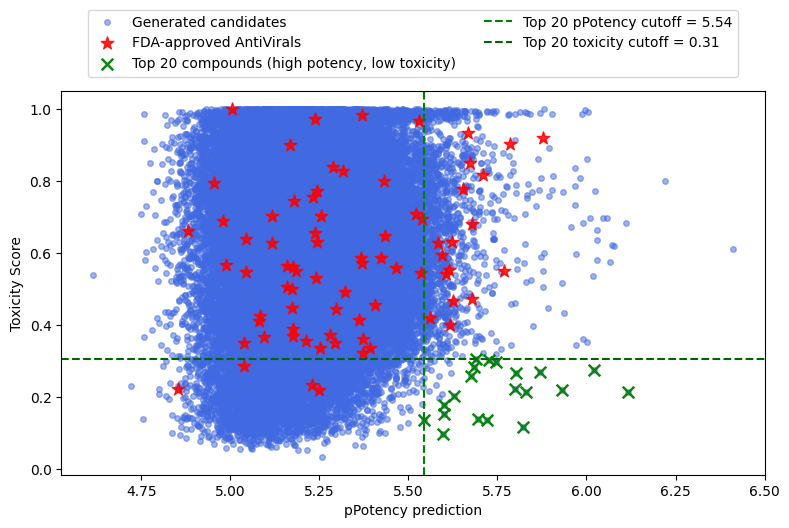

In [47]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)

ax.scatter(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    marker="*", s=90, alpha=0.85, color="red", label="FDA-approved AntiVirals"
)

ax.scatter(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.5,
    color="green",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.5,
    color="darkgreen",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_buyable.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### 15. Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

Selection rule:
- pPotency in the top quartile
- Toxicity Score in the bottom quartile
- ADMEFeasibility in the top quartile

Within that region, ranking uses the unweighted geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`
- `ADMEFeasibility`

In [48]:
cand3DDF = candScoreDF.copy()

cand3DDF = cand3DDF[
    cand3DDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff3D = cand3DDF["pPotency_prediction"].quantile(0.75)
yCutoff3D = cand3DDF["coreToxicityScore"].quantile(0.25)
zCutoff3D = cand3DDF["ADMEFeasibility"].quantile(0.75)

optimal3DDF = cand3DDF[
    (cand3DDF["pPotency_prediction"] >= xCutoff3D) &
    (cand3DDF["coreToxicityScore"] <= yCutoff3D) &
    (cand3DDF["ADMEFeasibility"] >= zCutoff3D)
].copy()

optimal3DDF["OverallPriority3D"] = (
    optimal3DDF["PotencyDesRaw"] *
    optimal3DDF["ToxicitySafety"] *
    optimal3DDF["ADMEFeasibility"]
) ** (1 / 3)

top20_3D_DF = optimal3DDF.sort_values(
    by=["OverallPriority3D", "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"],
    ascending=[False, False, True, False]
).head(20).copy()

top20_3D_DF["Top20Rank_3D"] = np.arange(1, len(top20_3D_DF) + 1)

top20_3D_DF[
    [
        "Top20Rank_3D",
        "smiles",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ADMEFeasibility",
        "ToxicitySafety",
        "OverallPriority3D",
        "QED",
    ]
]

,Top20Rank_3D,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ADMEFeasibility,ToxicitySafety,OverallPriority3D,QED
4494,1,CCC1(c2ccccc2)NC(=O)NC1=O,5.802353,0.545225,4.733711,0.267865,0.807699,0.732135,0.835610,0.709364
10478,2,COc1ccc(C2NC(=O)NC(C)=C2C(=O)OC(C)C)cc1OC,5.830609,0.549417,4.753751,0.214804,0.738309,0.785196,0.830097,0.807005
54580,3,COc1cccc(CC(=O)N2CCn3nnc(CCC(=O)N4CCCC4)c3C2)c1,5.627495,0.540206,4.568691,0.204176,0.780262,0.795824,0.817548,0.736629
664,4,CC(=O)NCC(=O)NCC1(c2ccncc2)CCCCC1,5.869404,0.547578,4.796152,0.270209,0.745556,0.729791,0.812736,0.863398
62079,5,Cc1c(C(=O)O)nnn1Cc1cccc(C(F)(F)F)c1,5.620942,0.541800,4.559014,0.268042,0.821575,0.731958,0.800604,0.939548
59030,6,COc1cccc(CN2C(=O)C3(CCOCC3)CC2c2nnnn2C(C)(C)C)...,5.498755,0.539894,4.440562,0.128749,0.812886,0.871251,0.798917,0.721557
32344,7,CC1=NN(C(=O)c2cccnc2)C(O)(c2cccnc2)C1,5.434135,0.544397,4.367117,0.100233,0.809207,0.899767,0.796240,0.905917
52651,8,COCCn1nnnc1C1CC2(CCOCC2)C(=O)N1CCc1ccc(OC)c(OC)c1,5.440766,0.539247,4.383842,0.140284,0.830636,0.859716,0.796147,0.574372
52652,9,COc1ccccc1OCCN1C(=O)C2(CCOCC2)CC1c1nnnn1C(C)(C)C,5.436684,0.540021,4.378242,0.165092,0.812896,0.834908,0.782761,0.696874
37391,10,COc1ccc(C(=O)N2CCn3c(C)nnc3C2)cc1OC,5.381866,0.541967,4.319611,0.109427,0.841186,0.890573,0.782673,0.853484


### 16. plot: pPotency vs Toxicity Score vs ADME feasibility

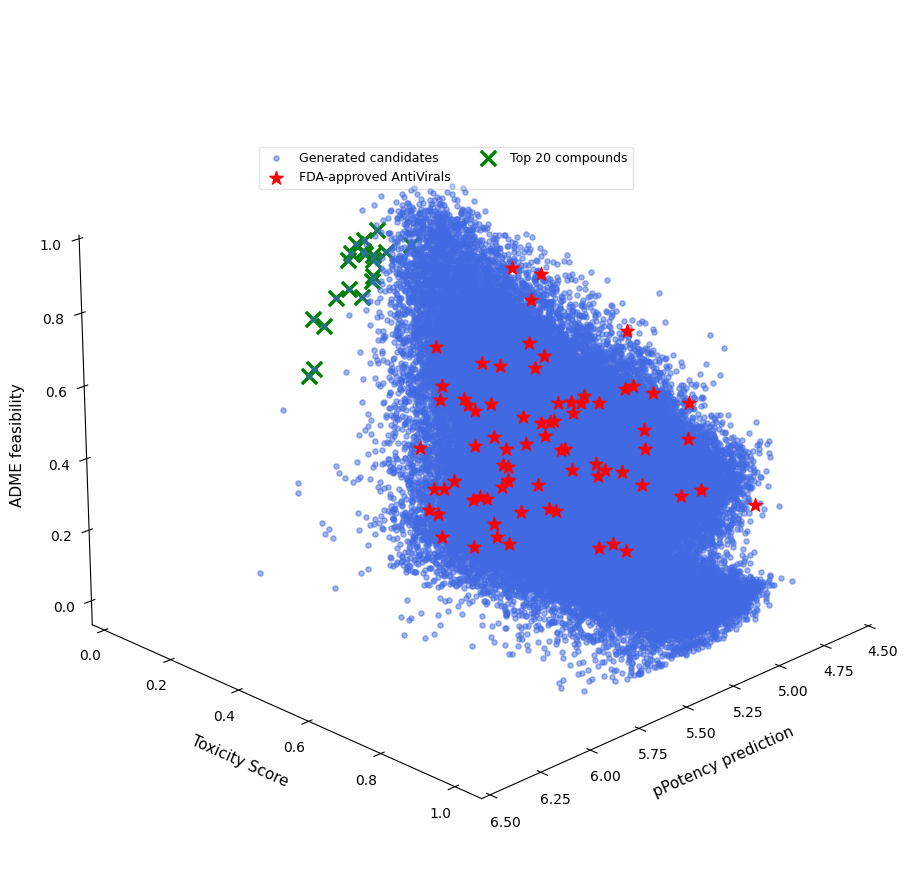

In [49]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13, 10))
ax  = fig.add_subplot(111, projection="3d")

fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor("lightgray")
    pane.set_alpha(0.0)

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]["linewidth"] = 0
    axis.label.set_color("k")
    axis.set_tick_params(colors="k")

ax.scatter(
    cand3DDF["pPotency_prediction"], cand3DDF["coreToxicityScore"], cand3DDF["ADMEFeasibility"],
    s=14, alpha=0.5, color="royalblue", label="Generated candidates", depthshade=False,
)
ax.scatter(
    refScoreDF["pPotency_prediction"], refScoreDF["coreToxicityScore"], refScoreDF["ADMEFeasibility"],
    marker="*", s=100, alpha=1.0, color="red", label="FDA-approved AntiVirals", depthshade=False,
)
ax.scatter(
    top20_3D_DF["pPotency_prediction"], top20_3D_DF["coreToxicityScore"], top20_3D_DF["ADMEFeasibility"],
    marker="x", s=120, linewidths=2.5, alpha=1.0, color="green", label="Top 20 compounds", depthshade=False,
)

xCutoff = top20_3D_DF["pPotency_prediction"].min()
yCutoff = top20_3D_DF["coreToxicityScore"].max()
zCutoff = top20_3D_DF["ADMEFeasibility"].min()

xMin, xMax = ax.get_xlim()
yMin, yMax = ax.get_ylim()
zMin, zMax = ax.get_zlim()

#cutoffStyle = dict(linewidth=1.8, linestyle="--", alpha=0.85)
#ax.plot([xMin,    xCutoff], [yCutoff, yCutoff], [zCutoff, zCutoff], color="green",     label=f"pPotency cutoff = {xCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yMax],    [zCutoff, zCutoff], color="darkolivegreen", label=f"Toxicity cutoff = {yCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yCutoff], [zMin,    zCutoff], color="seagreen",  label=f"ADME cutoff = {zCutoff:.2f}",    **cutoffStyle)
#ax.scatter([xCutoff], [yCutoff], [zCutoff], marker="D", s=180, color="gold", edgecolors="darkorange", linewidths=1.5, zorder=10, label="Optimal cutoff corner", depthshade=False)

ax.set_xlabel("pPotency prediction", labelpad=10, color="k", fontsize=11)
ax.set_ylabel("Toxicity Score", labelpad=10, color="k", fontsize=11)
ax.set_zlabel("ADME feasibility",    labelpad=10, color="k", fontsize=11)
ax.set_zlabel("")
ax.text2D(-0.02, 0.5, "ADME feasibility", transform=ax.transAxes, fontsize=11, color="k", rotation=90, va="center", ha="center")

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_tick_params(colors="k", labelsize=10)

ax.view_init(elev=22, azim=45)
ax.legend(loc="upper left", bbox_to_anchor=(0.25, 0.85), ncol=2, frameon=True, framealpha=0.3, facecolor="white", edgecolor="darkgray", labelcolor="black", fontsize=9)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_buyable.png")
plt.savefig(svg_path, format="svg", dpi=600, transparent=True, pad_inches=0.5)
plt.savefig(png_path, format="png", dpi=600, transparent=True, pad_inches=0.5)
plt.show()

### 17. Custom projected 3D plot for presentation

This is a presentation-oriented 2D projection of 3 variables.

Projected axes:
- horizontal right = `pPotency`
- vertical up = `Toxicity Score`
- diagonal lower-left = `ADME feasibility`

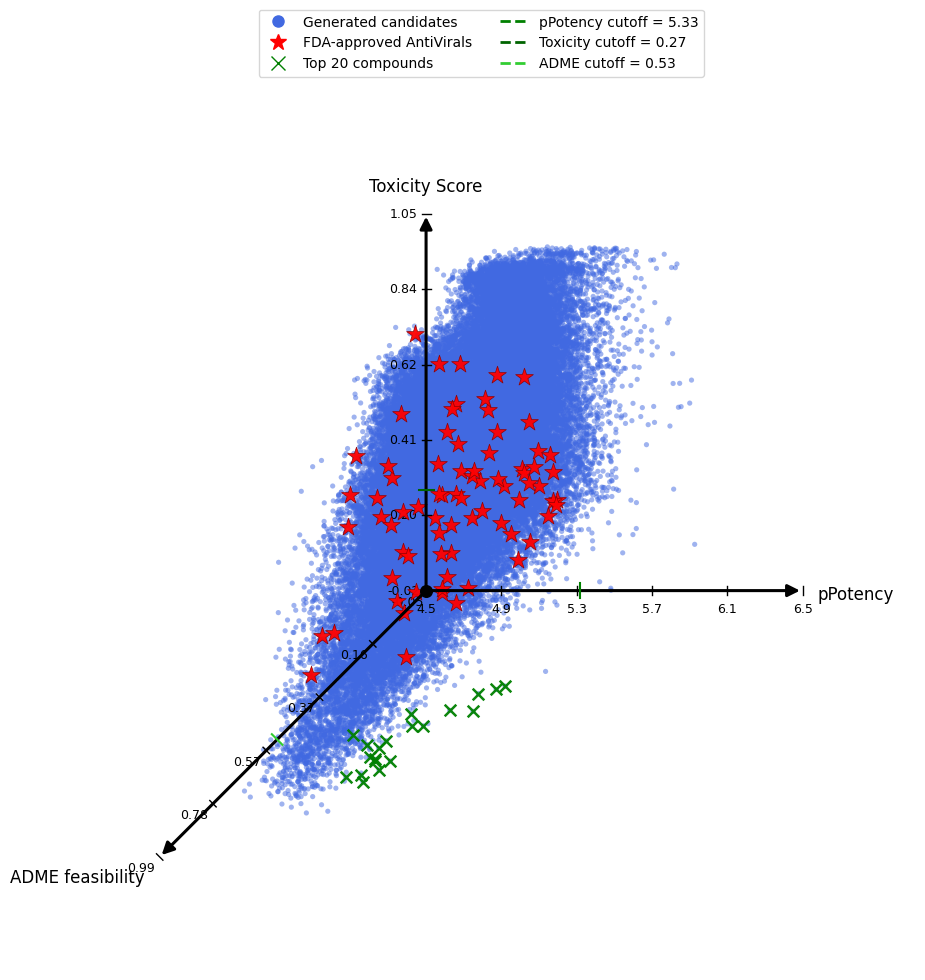

In [50]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = cand3DDF[cols][np.isfinite(cand3DDF[cols]).all(axis=1)].copy()
refPlotDF = refScoreDF[cols][np.isfinite(refScoreDF[cols]).all(axis=1)].copy()
topPlotDF = top20_3D_DF[cols][np.isfinite(top20_3D_DF[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined          = pd.concat([allPlotDF, refPlotDF, topPlotDF])
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x-X_MIN)/(X_MAX-X_MIN))*UX + ((y-Y_MIN)/(Y_MAX-Y_MIN))*UY + ((z-Z_MIN)/(Z_MAX-Z_MIN))*UZ

def projectDF(df):
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))

ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012*perp, pos + 0.012*perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t*(valMax-valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([ 0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06,  0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14,  alpha=0.5,  edgecolors="none", zorder=2)
ax.scatter(refCX, refCY, color="red",       s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green",     s=70,  alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02

UZ_perp = np.array([-UZ[1], UZ[0]]) 
UZ_perp /= np.linalg.norm(UZ_perp)           
zPt = O + ((zCut-Z_MIN)/(Z_MAX-Z_MIN))*UZ 

for pt, color, dx, dy in [
    (O + ((xCut-X_MIN)/(X_MAX-X_MIN))*UX, "green", 0, tickLen),
    (O + ((yCut-Y_MIN)/(Y_MAX-Y_MIN))*UY, "darkgreen",  tickLen, 0),
]:
    ax.plot([pt[0]-dx, pt[0]+dx], [pt[1]-dy, pt[1]+dy], color=color, lw=1.5, zorder=5)

# Z cutoff tick perpendicular to UZ
ax.plot(
    [zPt[0] - tickLen*UZ_perp[0], zPt[0] + tickLen*UZ_perp[0]],
    [zPt[1] - tickLen*UZ_perp[1], zPt[1] + tickLen*UZ_perp[1]],
    color="limegreen", lw=1.5, zorder=5
)

ax.text(TIP_X[0]+0.04, TIP_X[1]-0.01, "pPotency",            fontsize=12, ha="left",   va="center")
ax.text(TIP_Y[0],      TIP_Y[1]+0.05, "Toxicity Score",  fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0]-0.04, TIP_Z[1]-0.03, "ADME feasibility",    fontsize=12, ha="right",  va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min()-0.3, allPx.max()+0.3)
ax.set_ylim(allPy.min()-0.3, allPy.max()+0.3)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red",       marker="*", linestyle="None", markersize=12, label="FDA-approved AntiVirals"),
    mlines.Line2D([], [], color="green",     marker="x", linestyle="None", markersize=10, label="Top 20 compounds"),
    mlines.Line2D([], [], color="green",     linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_buyable.svg"), format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_buyable.png"), format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

### 18. Save the top 20 candidates

In [51]:
top20_2D_cols = ["Top20Rank_2D", "smiles", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ToxicitySafety", "OverallPriority2D", "QED"]
top20_3D_cols = ["Top20Rank_3D", "smiles", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "OverallPriority3D", "QED"]

toxicityTop20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_top20_buyable.csv")
admetTop20Path    = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_adme_top20_buyable.csv")

top20_2D_DF[top20_2D_cols[1:]].to_csv(toxicityTop20Path, index=False)
top20_3D_DF[top20_3D_cols[1:]].to_csv(admetTop20Path,    index=False)

print(f"Saved:\n- {toxicityTop20Path}\n- {admetTop20Path}")

#display(top20_2D_DF[top20_2D_cols])
#display(top20_3D_DF[top20_3D_cols])

Saved:
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_potency_coreToxicity_top20_buyable.csv
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_potency_coreToxicity_adme_top20_buyable.csv


# Check ADMET properties for `DOranet + DORA-XGB` generated AntiVirals
- Starter - `Inosine + Adenosine + Guanosine + Xanthosine`

### 1. Read `ART` predicted `pPotency` of all the compounds

In [61]:
Ebola_wART_DORAnetGenerated_Antivirals_predicted_all = pd.read_csv(saveDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')
max_val = Ebola_wART_DORAnetGenerated_Antivirals_predicted_all['pPotency_prediction'].max()
min_val = Ebola_wART_DORAnetGenerated_Antivirals_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_wART_DORAnetGenerated_Antivirals_predicted_all

pPotency_prediction range: 4.470 → 5.649


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,5.260644,0.540668,4.200935,6.320352,0.000005,4.782418e-07,0.000063
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040
...,...,...,...,...,...,...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,5.255267,0.543298,4.190404,6.320131,0.000006,4.784854e-07,0.000065
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.260999,0.542954,4.196810,6.325188,0.000005,4.729461e-07,0.000064
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.269796,0.541144,4.209154,6.330439,0.000005,4.672626e-07,0.000062
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,5.209218,0.543006,4.144925,6.273511,0.000006,5.327083e-07,0.000072


### Retain only the molecules produced through high-feasibility reactions, as validated by the DPRA-XGB classifier.

In [62]:
doraxgbDir='/users/sghosh6/DTRA_project/MACAW/doranet/scripts'
highFeasibility_molecules_fromInosine = pd.read_csv(doraxgbDir + '/Inosine_Pubchem/InosineOnly_gen3/InosineOnly_gen3_uniqueMolecules.csv')
highFeasibility_molecules_fromGuanosine = pd.read_csv(doraxgbDir + '/Guanosine_Pubchem/GuanosineOnly_gen3/GuanosineOnly_gen3_uniqueMolecules.csv')
highFeasibility_molecules_fromAdenosine = pd.read_csv(doraxgbDir + '/Adenosine_Pubchem/AdenosineOnly_gen3/AdenosineOnly_uniqueMolecules.csv')
highFeasibility_molecules_fromXanthosine = pd.read_csv(doraxgbDir + '/Xanthosine_Pubchem/XanthosineOnly_gen3/XanthosineOnly_gen3_uniqueMolecules.csv')

allDORAnetGenerated_highFeasibility_molecules = pd.concat([
    highFeasibility_molecules_fromInosine,
    highFeasibility_molecules_fromGuanosine,
    highFeasibility_molecules_fromAdenosine,
    highFeasibility_molecules_fromXanthosine
], ignore_index=True)

print(f"Inosine shape    : {highFeasibility_molecules_fromInosine.shape}")
print(f"Guanosine shape  : {highFeasibility_molecules_fromGuanosine.shape}")
print(f"Adenosine shape  : {highFeasibility_molecules_fromAdenosine.shape}")
print(f"Xanthosine shape : {highFeasibility_molecules_fromXanthosine.shape}")
print(f"Combined shape   : {allDORAnetGenerated_highFeasibility_molecules.shape}")

Inosine shape    : (782, 5)
Guanosine shape  : (1828, 5)
Adenosine shape  : (1343, 5)
Xanthosine shape : (1005, 5)
Combined shape   : (4958, 5)


In [63]:
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

# Canonicalize SMILES in both DataFrames
Ebola_wART_DORAnetGenerated_Antivirals_predicted_all["canon_SMILES"] = \
    Ebola_wART_DORAnetGenerated_Antivirals_predicted_all["SMILES"].apply(canonicalize)

allDORAnetGenerated_highFeasibility_molecules["canon_SMILES"] = \
    allDORAnetGenerated_highFeasibility_molecules["SMILES"].apply(canonicalize)

# Get valid canonical SMILES set from highFeasibility
highFeasibility_set = set(allDORAnetGenerated_highFeasibility_molecules["canon_SMILES"].dropna())

# Filter: keep only SMILES present in highFeasibility
Ebola_wART_DORAnetGenerated_Antivirals_predicted_all = \
    Ebola_wART_DORAnetGenerated_Antivirals_predicted_all[
        Ebola_wART_DORAnetGenerated_Antivirals_predicted_all["canon_SMILES"].isin(highFeasibility_set)
    ].drop(columns="canon_SMILES").reset_index(drop=True)

print(f"Filtered shape: {Ebola_wART_DORAnetGenerated_Antivirals_predicted_all.shape}")

Filtered shape: (4845, 10)


### plot `pPotency` distribution with error bars

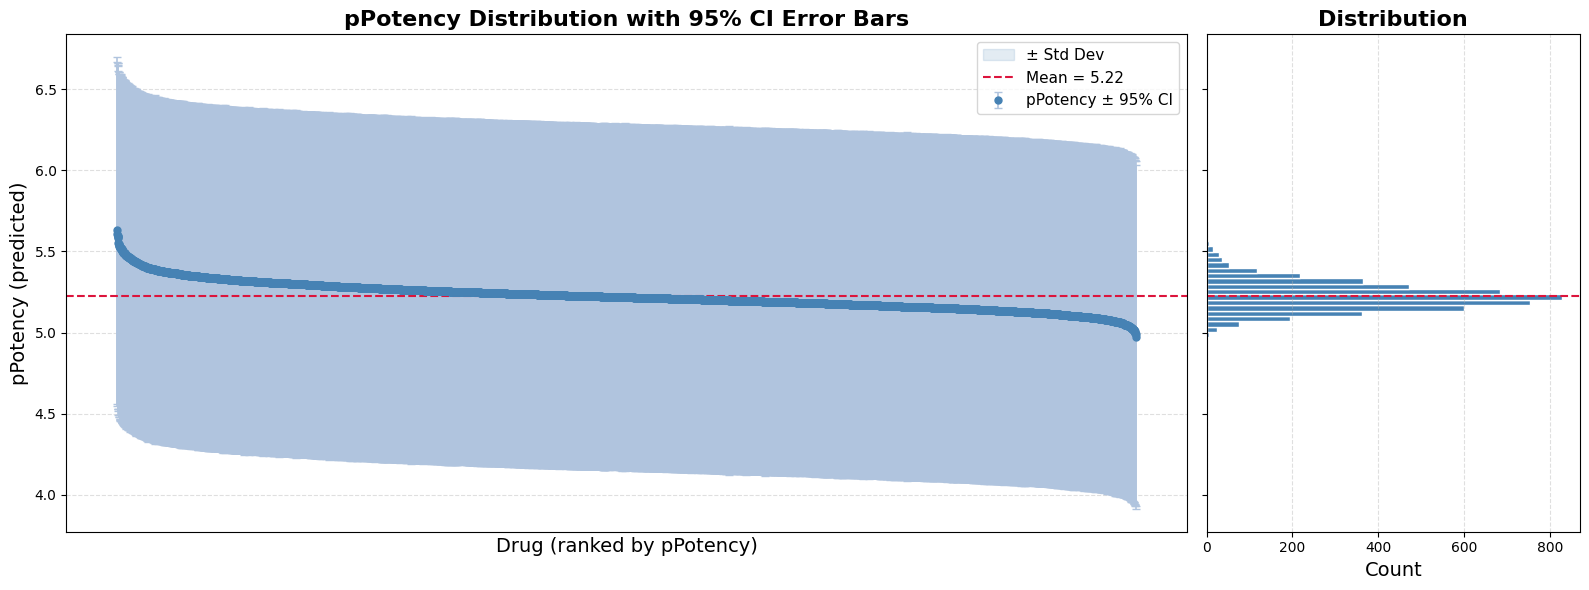

In [64]:
ppotencyDF = Ebola_wART_DORAnetGenerated_Antivirals_predicted_all.sort_values(
    "pPotency_prediction", ascending=False).reset_index(drop=True)

x = np.arange(len(ppotencyDF))
pred = ppotencyDF["pPotency_prediction"]
yerr = np.array([pred - ppotencyDF["pPotency_lower_95CI"],
                 ppotencyDF["pPotency_upper_95CI"] - pred])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

# ── Scatter + error bars ──────────────────────────────────────────────────────
ax1.errorbar(x, pred, yerr=yerr, fmt='o', color='steelblue', ecolor='lightsteelblue',
             elinewidth=1.2, capsize=3, markersize=5, alpha=1, label="pPotency ± 95% CI")
ax1.fill_between(x, pred - ppotencyDF["pPotency_std"], pred + ppotencyDF["pPotency_std"],
                 alpha=0.15, color='steelblue', label="± Std Dev")
ax1.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {pred.mean():.2f}')
#ax1.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {pred.median():.2f}')
ax1.set_xlabel("Drug (ranked by pPotency)", fontsize=14)  
ax1.set_ylabel("pPotency (predicted)",      fontsize=14) 
ax1.set_title("pPotency Distribution with 95% CI Error Bars", fontsize=16, fontweight='bold')  
ax1.set_xticks([])
ax1.legend(fontsize=11); ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Histogram ─────────────────────────────────────────────────────────────────
ax2.hist(pred, bins=20, orientation='horizontal', color='steelblue', edgecolor='white', alpha=1)
ax2.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5)
#ax2.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5)
ax2.set_xlabel("Count", fontsize=14)        
ax2.set_title("Distribution", fontsize=16, fontweight='bold') 
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_DORAnetGenerated_Antivirals.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_DORAnetGenerated_Antivirals.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Read predicted `ADMET` properties for all candidate SMILES

In [65]:
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity = pd.read_csv(saveDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction_wToxicity.csv')
# Identify columns that match the string
matched_cols = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.drop(columns=matched_cols)
max_val = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity

pPotency_prediction range: 4.470 → 5.649


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040,268.229,-2.26890,...,-5.835234,28.025204,-17.188645,4.934540,-24.011630,2.159634,-1.774638,31.001650,-1.080324,-1.642514
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053,507.182,-1.62900,...,-6.532908,10.607536,21.695647,50.300162,-17.205968,1.654107,0.655960,57.025779,-0.437743,-4.687410
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041,785.557,-2.42396,...,-6.475772,-3.364867,23.998967,23.188328,-17.767413,2.572223,0.824762,72.098404,-1.021829,-8.492948
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040,787.573,-1.75026,...,-6.679487,1.394358,30.020669,41.759685,-18.648854,2.694055,1.037456,70.919499,-0.882326,-5.521714
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.346715,0.540573,4.287192,6.406237,0.000005,3.924304e-07,0.000052,744.417,-2.89890,...,-6.818474,5.750305,18.362396,75.728975,-19.110544,1.835266,0.205004,52.787176,0.022007,-3.040320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7312,N#CC(O)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[n...,5.311236,0.542423,4.248086,6.374385,0.000005,4.222944e-07,0.000056,350.247,-3.86964,...,-5.955260,-8.761916,-26.770016,14.103317,-22.354659,3.105875,-1.044692,56.499127,-1.956776,2.486373
7313,N#CC(O)(O)[C@H]1O[C@](C#N)(n2cnc3c(=O)[nH]c(=O...,5.157317,0.542338,4.094336,6.220299,0.000007,6.021448e-07,0.000080,350.247,-4.08564,...,-5.818521,-13.439529,-30.363843,23.556845,-21.883500,3.207771,-1.054912,57.989126,-2.152616,-1.152304
7314,N#Cc1nc2c(=O)[nH]c(=O)[nH]c2n1[C@@H]1O[C@H](C(...,5.297589,0.541998,4.235274,6.359904,0.000005,4.366119e-07,0.000058,350.247,-3.89174,...,-5.849040,-4.257238,-21.835345,18.294608,-21.778549,3.044578,-0.985986,57.468950,-2.193930,-0.049402
7315,O=C1NC2=NC(=O)[C@H]3O[C@H]([C@H](O)[C@@H]3O)n3...,5.303743,0.541890,4.241639,6.365846,0.000005,4.306792e-07,0.000057,279.212,-2.07580,...,-5.684864,-9.842546,-16.313448,76.343168,-23.489791,2.280219,-1.492284,34.876469,-2.238372,-4.511073


In [66]:
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

# Canonicalize SMILES in both DataFrames
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity["canon_SMILES"] = \
    Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity["SMILES"].apply(canonicalize)

allDORAnetGenerated_highFeasibility_molecules["canon_SMILES"] = \
    allDORAnetGenerated_highFeasibility_molecules["SMILES"].apply(canonicalize)

# Get valid canonical SMILES set from highFeasibility
highFeasibility_set = set(allDORAnetGenerated_highFeasibility_molecules["canon_SMILES"].dropna())

# Filter: keep only SMILES present in highFeasibility
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity = \
    Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity[
        Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity["canon_SMILES"].isin(highFeasibility_set)
    ].drop(columns="canon_SMILES").reset_index(drop=True)

print(f"Filtered shape: {Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.shape}")

Filtered shape: (1474, 57)


### 2. AntiViral candidate prioritization by comparing with `Drugbank`

In [67]:
refDrugbankDF = drugBankDrug_FDAapproved_AntiViral_wART_wADMET.copy()
generatedCandidateDF = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)

Drugbank reference dataframe shape: (75, 44)
Generated candidate dataframe shape: (1474, 57)


### 3. Harmonize metadata and the SMILES column

The candidate dataframe may use `SMILES` instead of `smiles`.  
This cell standardizes that and fills a few metadata fields if they are missing.

In [68]:
if "SMILES" in generatedCandidateDF.columns:
    generatedCandidateDF = generatedCandidateDF.rename(columns={"SMILES": "smiles"})

if "ATC_code" not in generatedCandidateDF.columns:
    generatedCandidateDF["ATC_code"] = pd.NA

if "Drug_Type" not in generatedCandidateDF.columns:
    generatedCandidateDF["Drug_Type"] = "Predicted_candidate"

if "source_DataBase" not in generatedCandidateDF.columns:
    generatedCandidateDF["source_DataBase"] = "Generated"

refDrugbankDF["datasetLabel"] = "FDA-approved AntiVirals"
generatedCandidateDF["datasetLabel"] = "Generated candidates"

print("smiles in refDrugbankDF:", "smiles" in refDrugbankDF.columns)
print("smiles in generatedCandidateDF:", "smiles" in generatedCandidateDF.columns)

smiles in refDrugbankDF: True
smiles in generatedCandidateDF: True


### 4. Define `ADMET` column groups

We keep:
- metadata
- potency-related columns
- toxicity-related columns
- ADME-related columns
- a few physicochemical property columns such as `QED`, `logP` and `molecular_weight`

In [69]:
metadataCols = [
    "smiles",
    "ATC_code",
    "Drug_Type",
    "source_DataBase",
    "datasetLabel",
]

potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "IC50(M)_prediction",
    "IC50(M)_lower_95CI",
    "IC50(M)_upper_95CI",
]

toxicityCols = [
    "AMES",
    "Carcinogens_Lagunin",
    "ClinTox",
    "DILI",
    "Skin_Reaction",
    "hERG",
    "LD50_Zhu",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]

admeCols = [
    "Bioavailability_Ma",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Caco2_Wang",
    "Solubility_AqSolDB",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
    "Pgp_Broccatelli",
    "Clearance_Hepatocyte_AZ",
    "Clearance_Microsome_AZ",
    "Half_Life_Obach",
    "PPBR_AZ",
    "VDss_Lombardo",
]

optionalCols = ["BBB_Martins"]

physicochemCols = [
    "molecular_weight",
    "logP",
    "hydrogen_bond_acceptors",
    "hydrogen_bond_donors",
    "Lipinski",
    "QED",
    "stereo_centers",
    "tpsa",
    "HydrationFreeEnergy_FreeSolv",
    "Lipophilicity_AstraZeneca",
]

keepCols = list(dict.fromkeys(metadataCols + potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))
print("Total kept columns:", len(keepCols))

Total kept columns: 61


### 5. Build aligned reference and candidate dataframes

This cell keeps the same columns in both dataframes and creates any missing columns as `NaN`

In [70]:
def ensureCols(DF, colList):
    outDF = DF.copy()
    for colName in colList:
        if colName not in outDF.columns:
            outDF[colName] = np.nan
    return outDF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)

print("Reference aligned shape:", refScoreDF.shape)
print("Candidate aligned shape:", candScoreDF.shape)

Reference aligned shape: (75, 61)
Candidate aligned shape: (1474, 61)


### 6. Convert relevant columns to numeric

All scoring-related columns are converted to numeric.  

In [71]:
numericCols = list(dict.fromkeys(potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))

for colName in numericCols:
    if colName in refScoreDF.columns:
        refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    if colName in candScoreDF.columns:
        candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")

refScoreDF["potencyConservative"] = refScoreDF["pPotency_lower_95CI"].fillna(refScoreDF["pPotency_prediction"])
candScoreDF["potencyConservative"] = candScoreDF["pPotency_lower_95CI"].fillna(candScoreDF["pPotency_prediction"])

### 7. Define endpoint metadata

This table contains:
- endpoint name
- whether it belongs to the **toxicity** or **adme** group
- the direction of desirability:
  - `lowerBetter`
  - `higherBetter`
  - `referenceMatch`


In [72]:
endpointMetaDF = pd.DataFrame([
    # Toxicity
    {"endpoint": "AMES",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Carcinogens_Lagunin", "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "ClinTox",             "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "DILI",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Skin_Reaction",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "hERG",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "LD50_Zhu",            "majorGroup": "toxicity", "direction": "higherBetter"},
    {"endpoint": "NR-AR-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AR",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AhR",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-Aromatase",        "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-PPAR-gamma",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ARE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ATAD5",            "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-HSE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-MMP",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-p53",              "majorGroup": "toxicity", "direction": "lowerBetter"},

    # ADME
    {"endpoint": "Bioavailability_Ma",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "HIA_Hou",                        "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "PAMPA_NCATS",                    "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Caco2_Wang",                     "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Solubility_AqSolDB",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "CYP1A2_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C19_Veith",                  "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C9_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2C9_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2D6_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2D6_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP3A4_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP3A4_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "Pgp_Broccatelli",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Hepatocyte_AZ",        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Microsome_AZ",         "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Half_Life_Obach",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "PPBR_AZ",                        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "VDss_Lombardo",                  "majorGroup": "adme", "direction": "referenceMatch"},
])

endpointMetaDF

,endpoint,majorGroup,direction
0,AMES,toxicity,lowerBetter
1,Carcinogens_Lagunin,toxicity,lowerBetter
2,ClinTox,toxicity,lowerBetter
3,DILI,toxicity,lowerBetter
4,Skin_Reaction,toxicity,lowerBetter
5,hERG,toxicity,lowerBetter
6,LD50_Zhu,toxicity,higherBetter
7,NR-AR-LBD,toxicity,lowerBetter
8,NR-AR,toxicity,lowerBetter
9,NR-AhR,toxicity,lowerBetter


### 8. Derive fully statistical endpoint weights from FDA-approved AntiVirals from `Drugbank`

For each endpoint we compute:

- **informativeness** = inverse of the reference IQR  
  A tighter approved-AntiViral distribution means the endpoint is more constrained and therefore more informative.

- **uniqueness** = inverse redundancy penalty  
  Endpoints that are highly correlated with other endpoints in the same group get reduced weight.

The final endpoint weights are normalized inside each major group:
- `toxicity`
- `adme`

In [73]:
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

weightRows = []

for majorGroupName in endpointMetaDF["majorGroup"].unique():
    groupMetaDF = endpointMetaDF[endpointMetaDF["majorGroup"] == majorGroupName].copy()
    groupEndpoints = groupMetaDF["endpoint"].tolist()

    groupRefDF = refScoreDF[groupEndpoints].apply(pd.to_numeric, errors="coerce")
    groupCorrDF = groupRefDF.corr().abs()

    for endpointName in groupEndpoints:
        series = groupRefDF[endpointName]
        iqrValue = robustIQR(series)

        informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

        otherEndpoints = [x for x in groupEndpoints if x != endpointName]
        if len(otherEndpoints) > 0 and endpointName in groupCorrDF.index:
            meanAbsCorr = groupCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
            uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        else:
            uniqueness = 1.0

        rawWeight = informativeness * uniqueness

        weightRows.append({
            "endpoint": endpointName,
            "majorGroup": majorGroupName,
            "direction": groupMetaDF.loc[groupMetaDF["endpoint"] == endpointName, "direction"].iloc[0],
            "iqrValue": iqrValue,
            "informativeness": informativeness,
            "uniqueness": uniqueness,
            "rawWeight": rawWeight,
        })

weightDF = pd.DataFrame(weightRows)
weightDF["finalWeight"] = (
    weightDF.groupby("majorGroup")["rawWeight"]
    .transform(lambda x: x / x.sum())
)

weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
20,HIA_Hou,adme,higherBetter,0.021880,45.702296,0.664728,30.379574,0.448401
24,CYP1A2_Veith,adme,lowerBetter,0.093155,10.734647,0.774213,8.310900,0.122669
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.116814,8.560575,0.669611,5.732252,0.084608
29,CYP2D6_Veith,adme,lowerBetter,0.117351,8.521400,0.626252,5.336541,0.078767
19,Bioavailability_Ma,adme,higherBetter,0.212015,4.716615,0.757873,3.574597,0.052761
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.225672,4.431191,0.593906,2.631713,0.038844
22,Caco2_Wang,adme,higherBetter,0.556913,1.795609,0.664372,1.192952,0.017608
23,Solubility_AqSolDB,adme,higherBetter,NaN,1.000000,1.000000,1.000000,0.014760
33,Clearance_Hepatocyte_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760
34,Clearance_Microsome_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760


### 9. Helper functions for desirability scoring and weighted aggregation

This section defines:

- percentile-based desirability functions
- a reference-matching desirability function
- weighted geometric mean aggregation

In [74]:
def getSortedRefArray(refSeries):
    refArray = pd.to_numeric(refSeries, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    refArray = np.sort(refArray)
    return refArray

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def referenceMatchDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    refMedian = np.nanmedian(refArray)
    q25, q75 = np.nanpercentile(refArray, [25, 75])
    robustSigma = (q75 - q25) / 1.349 if q75 > q25 else np.nanstd(refArray)

    if not np.isfinite(robustSigma) or robustSigma <= 0:
        robustSigma = 1e-6

    finiteMask = np.isfinite(valueArray)
    zArray = (valueArray[finiteMask] - refMedian) / robustSigma
    outArray[finiteMask] = np.exp(-0.5 * (zArray ** 2))
    outArray = np.clip(outArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan, dtype=float)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

### 10. Convert endpoints into 0–1 desirability scores

Every endpoint becomes a new `*_des` column.
We also compute `PotencyDesRaw` from the reference AntiViral potency distribution.

In [75]:
for _, rowDF in weightDF.iterrows():
    endpointName = rowDF["endpoint"]
    directionName = rowDF["direction"]
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        refScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "lowerBetter":
        refScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "referenceMatch":
        refScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], candScoreDF[endpointName])

refScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    refScoreDF["pPotency_prediction"]
)

candScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    candScoreDF["pPotency_prediction"]
)
refScoreDF

,smiles,ATC_code,Drug_Type,source_DataBase,datasetLabel,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,...,CYP2D6_Veith_des,CYP3A4_Substrate_CarbonMangels_des,CYP3A4_Veith_des,Pgp_Broccatelli_des,Clearance_Hepatocyte_AZ_des,Clearance_Microsome_AZ_des,Half_Life_Obach_des,PPBR_AZ_des,VDss_Lombardo_des,PotencyDesRaw
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.237696,0.541353,4.176643,6.298748,0.000006,...,0.680000,0.749483,0.546667,0.837055,NaN,NaN,NaN,NaN,NaN,0.386667
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.037581,0.543129,3.973048,6.102114,0.000009,...,0.866667,0.468450,0.893333,0.829210,NaN,NaN,NaN,NaN,NaN,0.093333
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.233644,0.545209,4.165035,6.302253,0.000006,...,0.626667,0.892440,0.386667,0.998700,NaN,NaN,NaN,NaN,NaN,0.373333
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.175844,0.542325,4.112886,6.238802,0.000007,...,0.080000,0.989583,0.053333,0.978069,NaN,NaN,NaN,NaN,NaN,0.293333
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.626048,0.541898,4.563928,6.688167,0.000002,...,0.253333,0.865070,0.026667,0.978080,NaN,NaN,NaN,NaN,NaN,0.880000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,J05AB,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.536453,0.540180,4.477700,6.595206,0.000003,...,0.826667,0.500345,0.826667,0.825648,NaN,NaN,NaN,NaN,NaN,0.760000
71,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,J05AP,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.878781,0.543114,4.814277,6.943285,0.000001,...,0.586667,0.944027,0.266667,0.969470,NaN,NaN,NaN,NaN,NaN,1.000000
72,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,J05AF,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.039875,0.540991,3.979532,6.100217,0.000009,...,0.933333,0.495126,0.853333,0.824738,NaN,NaN,NaN,NaN,NaN,0.106667
73,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,J05AH,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.297290,0.545680,4.227758,6.366822,0.000005,...,0.386667,0.465962,0.986667,0.825159,NaN,NaN,NaN,NaN,NaN,0.533333


### 11. Directly aggregate within the two separate ADMET groups

This notebook uses:
- one direct **toxicity** aggregate
- one direct **adme** aggregate

Then we define:
- `ToxicitySafety`
- `Toxicity Score = 1 - ToxicitySafety`
- `ADMEFeasibility`

In [76]:
toxWeightDF = weightDF[weightDF["majorGroup"] == "toxicity"].copy()
admeWeightDF = weightDF[weightDF["majorGroup"] == "adme"].copy()

toxDesCols = [f"{endpointName}_des" for endpointName in toxWeightDF["endpoint"]]
admeDesCols = [f"{endpointName}_des" for endpointName in admeWeightDF["endpoint"]]

refScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    refScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)
candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)

refScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    refScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)
candScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    candScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)

refScoreDF["coreToxicityScore"] = 1.0 - refScoreDF["ToxicitySafety"]
candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]

refScoreDF["ToxicityBurden"] = refScoreDF["coreToxicityScore"]
candScoreDF["ToxicityBurden"] = candScoreDF["coreToxicityScore"]

refScoreDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pPotency_prediction,75.0,5.329120,0.235755,4.852256,5.173378,5.289192,5.533146,5.878781
coreToxicityScore,75.0,0.585980,0.199487,0.219589,0.421852,0.564323,0.705460,0.999424
ADMEFeasibility,75.0,0.429011,0.187771,0.080314,0.314571,0.432448,0.551611,0.837525


## 12. Inspect the statistically derived endpoint weights

In [77]:
weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
20,HIA_Hou,adme,higherBetter,0.021880,45.702296,0.664728,30.379574,0.448401
24,CYP1A2_Veith,adme,lowerBetter,0.093155,10.734647,0.774213,8.310900,0.122669
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.116814,8.560575,0.669611,5.732252,0.084608
29,CYP2D6_Veith,adme,lowerBetter,0.117351,8.521400,0.626252,5.336541,0.078767
19,Bioavailability_Ma,adme,higherBetter,0.212015,4.716615,0.757873,3.574597,0.052761
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.225672,4.431191,0.593906,2.631713,0.038844
22,Caco2_Wang,adme,higherBetter,0.556913,1.795609,0.664372,1.192952,0.017608
23,Solubility_AqSolDB,adme,higherBetter,NaN,1.000000,1.000000,1.000000,0.014760
33,Clearance_Hepatocyte_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760
34,Clearance_Microsome_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760


### 13. Plot: `high pPotency` and `low Toxicity Score`

Selection rule:
- pPotency in the top quartile of generated compounds
- Toxicity Score in the bottom quartile of generated compounds

Within that selected region, ranking uses the geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`

In [78]:
cand2DDF = candScoreDF.copy()

cand2DDF = cand2DDF[
    cand2DDF[["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

top20_2D_DF["Top20Rank_2D"] = np.arange(1, len(top20_2D_DF) + 1)

top20_2D_DF[
    [
        "Top20Rank_2D",
        "smiles",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ToxicitySafety",
        "OverallPriority2D",
        "QED",
    ]
]

,Top20Rank_2D,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ToxicitySafety,OverallPriority2D,QED
22,1,O=C(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,5.439854,0.540909,4.379672,0.222625,0.777375,0.741178,0.485234
617,2,COC(=O)OP(=O)(O)O,5.348856,0.542413,4.285727,0.029607,0.970393,0.737170,0.405060
280,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](C(=O)O)[C@@H](O)[C...,5.548892,0.539839,4.490807,0.304550,0.695450,0.733359,0.493710
538,4,O=COP(=O)(O)O,5.317889,0.543077,4.253458,0.016644,0.983356,0.733190,0.375363
618,5,CC(O)OP(=O)(O)O,5.335041,0.543682,4.269424,0.072561,0.927439,0.720670,0.354812
401,6,OC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.595065,0.543265,4.530266,0.390078,0.609922,0.704322,0.558802
228,7,COC(=O)O,5.303604,0.542347,4.240604,0.076156,0.923844,0.701938,0.422195
128,8,O=C(O)[C@H]1O[C@@H]2[C@H](O)[C@@H]1Oc1nc3c(ncn...,5.447498,0.540629,4.387865,0.306183,0.693817,0.700213,0.556867
400,9,Nc1ncnc2c1ncn2[C@@H]1OC[C@@H](O)[C@H]1O,5.490917,0.545010,4.422698,0.325715,0.674285,0.696768,0.561054
234,10,OCC(O)O,5.304038,0.543528,4.238723,0.103038,0.896962,0.691650,0.327154


### 14. plot: pPotency vs Toxicity Score

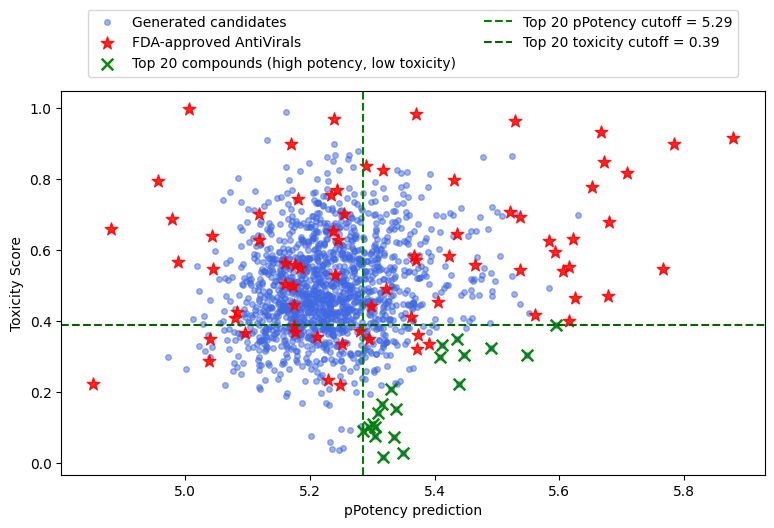

In [79]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)

ax.scatter(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    marker="*", s=90, alpha=0.85, color="red", label="FDA-approved AntiVirals"
)

ax.scatter(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.5,
    color="green",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.5,
    color="darkgreen",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_DORAnetGenerated_Antivirals.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_DORAnetGenerated_Antivirals.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### 15. Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

Selection rule:
- pPotency in the top quartile
- Toxicity Score in the bottom quartile
- ADMEFeasibility in the top quartile

Within that region, ranking uses the unweighted geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`
- `ADMEFeasibility`

In [80]:
cand3DDF = candScoreDF.copy()

cand3DDF = cand3DDF[
    cand3DDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff3D = cand3DDF["pPotency_prediction"].quantile(0.75)
yCutoff3D = cand3DDF["coreToxicityScore"].quantile(0.25)
zCutoff3D = cand3DDF["ADMEFeasibility"].quantile(0.75)

optimal3DDF = cand3DDF[
    (cand3DDF["pPotency_prediction"] >= xCutoff3D) &
    (cand3DDF["coreToxicityScore"] <= yCutoff3D) &
    (cand3DDF["ADMEFeasibility"] >= zCutoff3D)
].copy()

optimal3DDF["OverallPriority3D"] = (
    optimal3DDF["PotencyDesRaw"] *
    optimal3DDF["ToxicitySafety"] *
    optimal3DDF["ADMEFeasibility"]
) ** (1 / 3)

top20_3D_DF = optimal3DDF.sort_values(
    by=["OverallPriority3D", "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"],
    ascending=[False, False, True, False]
).head(20).copy()

top20_3D_DF["Top20Rank_3D"] = np.arange(1, len(top20_3D_DF) + 1)

top20_3D_DF[
    [
        "Top20Rank_3D",
        "smiles",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ADMEFeasibility",
        "ToxicitySafety",
        "OverallPriority3D",
        "QED",
    ]
]

,Top20Rank_3D,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ADMEFeasibility,ToxicitySafety,OverallPriority3D,QED
155,1,COC,5.294713,0.543597,4.229263,0.101738,0.821737,0.898262,0.720476,0.380040
213,2,CCO,5.338668,0.543588,4.273235,0.153545,0.744416,0.846455,0.706647,0.406808
157,3,COC(C)=O,5.285757,0.543428,4.220637,0.091076,0.706245,0.908924,0.681618,0.382967
703,4,CC1=Nc2ncnc3c2ncn3[C@@H]2O[C@@](C)(CO)[C@@H](O...,5.321167,0.541324,4.260172,0.360678,0.815168,0.639322,0.658006,0.756551
530,5,CO[C@H]1[C@H](n2cnc3c(N)ncnc32)O[C@@](C)(COC(C...,5.292663,0.541746,4.230841,0.356696,0.793536,0.643304,0.637140,0.716559
500,6,COC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.316491,0.542356,4.253474,0.363411,0.736643,0.636589,0.630045,0.643138
508,7,CO[C@@]1(C)[C@@H](CO)O[C@@H](n2cnc3c(NC(C)=O)n...,5.352073,0.542649,4.288481,0.335740,0.667631,0.664260,0.628571,0.676381
400,8,Nc1ncnc2c1ncn2[C@@H]1OC[C@@H](O)[C@H]1O,5.490917,0.545010,4.422698,0.325715,0.508993,0.674285,0.627523,0.561054
507,9,CO[C@@H]1[C@@H](CO)O[C@@H](n2cnc3c(NC(C)=O)ncn...,5.306528,0.542217,4.243781,0.307385,0.558372,0.692615,0.590842,0.676381
545,10,C[C@@]1(CO)O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C...,5.488559,0.541272,4.427666,0.395115,0.471342,0.604885,0.589903,0.516309


### 16. plot: pPotency vs Toxicity Score vs ADME feasibility

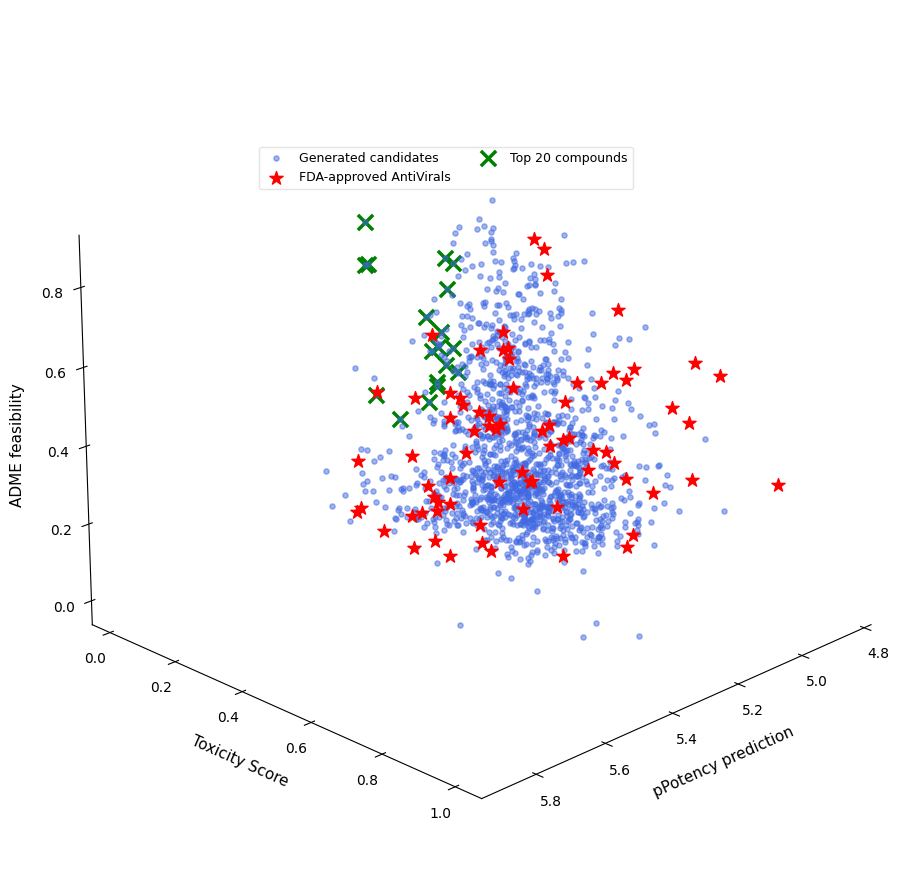

In [81]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13, 10))
ax  = fig.add_subplot(111, projection="3d")

fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor("lightgray")
    pane.set_alpha(0.0)

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]["linewidth"] = 0
    axis.label.set_color("k")
    axis.set_tick_params(colors="k")

ax.scatter(
    cand3DDF["pPotency_prediction"], cand3DDF["coreToxicityScore"], cand3DDF["ADMEFeasibility"],
    s=14, alpha=0.5, color="royalblue", label="Generated candidates", depthshade=False,
)
ax.scatter(
    refScoreDF["pPotency_prediction"], refScoreDF["coreToxicityScore"], refScoreDF["ADMEFeasibility"],
    marker="*", s=100, alpha=1.0, color="red", label="FDA-approved AntiVirals", depthshade=False,
)
ax.scatter(
    top20_3D_DF["pPotency_prediction"], top20_3D_DF["coreToxicityScore"], top20_3D_DF["ADMEFeasibility"],
    marker="x", s=120, linewidths=2.5, alpha=1.0, color="green", label="Top 20 compounds", depthshade=False,
)

xCutoff = top20_3D_DF["pPotency_prediction"].min()
yCutoff = top20_3D_DF["coreToxicityScore"].max()
zCutoff = top20_3D_DF["ADMEFeasibility"].min()

xMin, xMax = ax.get_xlim()
yMin, yMax = ax.get_ylim()
zMin, zMax = ax.get_zlim()

#cutoffStyle = dict(linewidth=1.8, linestyle="--", alpha=0.85)
#ax.plot([xMin,    xCutoff], [yCutoff, yCutoff], [zCutoff, zCutoff], color="green",     label=f"pPotency cutoff = {xCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yMax],    [zCutoff, zCutoff], color="darkolivegreen", label=f"Toxicity cutoff = {yCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yCutoff], [zMin,    zCutoff], color="seagreen",  label=f"ADME cutoff = {zCutoff:.2f}",    **cutoffStyle)
#ax.scatter([xCutoff], [yCutoff], [zCutoff], marker="D", s=180, color="gold", edgecolors="darkorange", linewidths=1.5, zorder=10, label="Optimal cutoff corner", depthshade=False)

ax.set_xlabel("pPotency prediction", labelpad=10, color="k", fontsize=11)
ax.set_ylabel("Toxicity Score", labelpad=10, color="k", fontsize=11)
ax.set_zlabel("ADME feasibility",    labelpad=10, color="k", fontsize=11)
ax.set_zlabel("")
ax.text2D(-0.02, 0.5, "ADME feasibility", transform=ax.transAxes, fontsize=11, color="k", rotation=90, va="center", ha="center")

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_tick_params(colors="k", labelsize=10)

ax.view_init(elev=22, azim=45)
ax.legend(loc="upper left", bbox_to_anchor=(0.25, 0.85), ncol=2, frameon=True, framealpha=0.3, facecolor="white", edgecolor="darkgray", labelcolor="black", fontsize=9)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_DORAnetGenerated_Antivirals.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_DORAnetGenerated_Antivirals.png")
plt.savefig(svg_path, format="svg", dpi=600, transparent=True, pad_inches=0.5)
plt.savefig(png_path, format="png", dpi=600, transparent=True, pad_inches=0.5)
plt.show()

### 17. Custom projected 3D plot for presentation

This is a presentation-oriented 2D projection of 3 variables.

Projected axes:
- horizontal right = `pPotency`
- vertical up = `Toxicity Score`
- diagonal lower-left = `ADME feasibility`

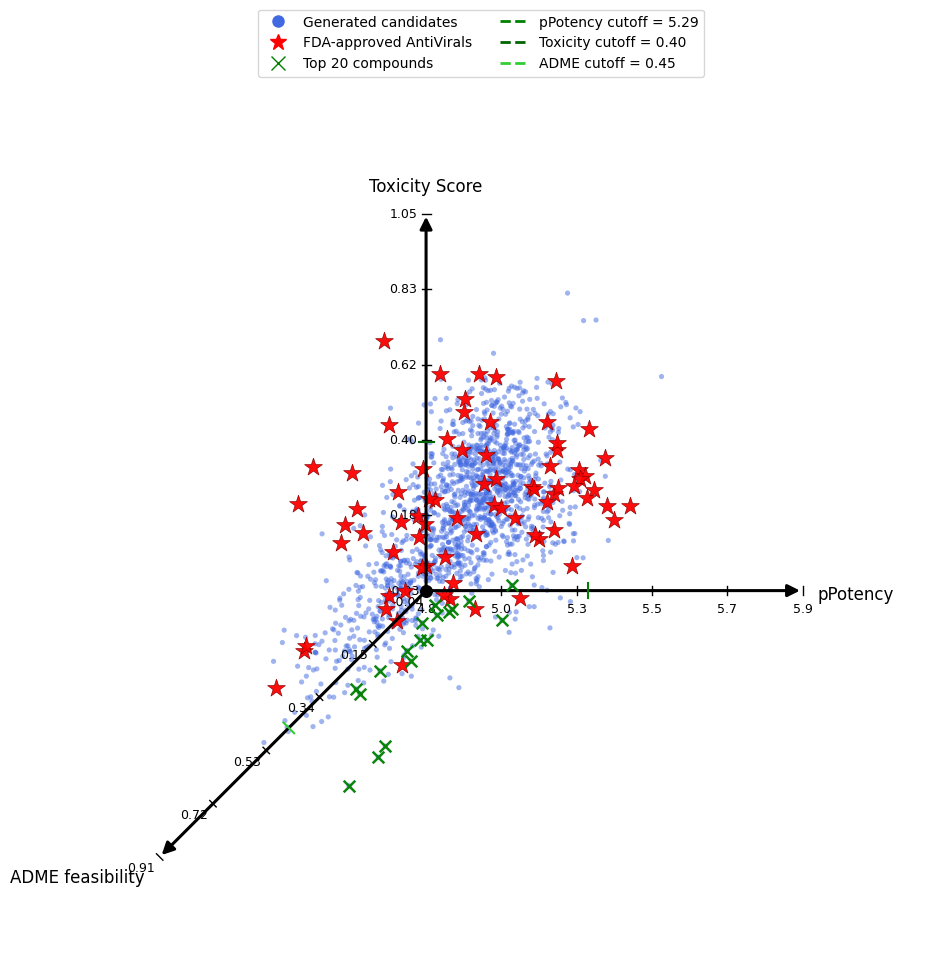

In [82]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = cand3DDF[cols][np.isfinite(cand3DDF[cols]).all(axis=1)].copy()
refPlotDF = refScoreDF[cols][np.isfinite(refScoreDF[cols]).all(axis=1)].copy()
topPlotDF = top20_3D_DF[cols][np.isfinite(top20_3D_DF[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined          = pd.concat([allPlotDF, refPlotDF, topPlotDF])
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x-X_MIN)/(X_MAX-X_MIN))*UX + ((y-Y_MIN)/(Y_MAX-Y_MIN))*UY + ((z-Z_MIN)/(Z_MAX-Z_MIN))*UZ

def projectDF(df):
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))

ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012*perp, pos + 0.012*perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t*(valMax-valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([ 0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06,  0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14,  alpha=0.5,  edgecolors="none", zorder=2)
ax.scatter(refCX, refCY, color="red",       s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green",     s=70,  alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02

UZ_perp = np.array([-UZ[1], UZ[0]]) 
UZ_perp /= np.linalg.norm(UZ_perp)           
zPt = O + ((zCut-Z_MIN)/(Z_MAX-Z_MIN))*UZ 

for pt, color, dx, dy in [
    (O + ((xCut-X_MIN)/(X_MAX-X_MIN))*UX, "green", 0, tickLen),
    (O + ((yCut-Y_MIN)/(Y_MAX-Y_MIN))*UY, "darkgreen",  tickLen, 0),
]:
    ax.plot([pt[0]-dx, pt[0]+dx], [pt[1]-dy, pt[1]+dy], color=color, lw=1.5, zorder=5)

# Z cutoff tick perpendicular to UZ
ax.plot(
    [zPt[0] - tickLen*UZ_perp[0], zPt[0] + tickLen*UZ_perp[0]],
    [zPt[1] - tickLen*UZ_perp[1], zPt[1] + tickLen*UZ_perp[1]],
    color="limegreen", lw=1.5, zorder=5
)

ax.text(TIP_X[0]+0.04, TIP_X[1]-0.01, "pPotency",            fontsize=12, ha="left",   va="center")
ax.text(TIP_Y[0],      TIP_Y[1]+0.05, "Toxicity Score",  fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0]-0.04, TIP_Z[1]-0.03, "ADME feasibility",    fontsize=12, ha="right",  va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min()-0.3, allPx.max()+0.3)
ax.set_ylim(allPy.min()-0.3, allPy.max()+0.3)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red",       marker="*", linestyle="None", markersize=12, label="FDA-approved AntiVirals"),
    mlines.Line2D([], [], color="green",     marker="x", linestyle="None", markersize=10, label="Top 20 compounds"),
    mlines.Line2D([], [], color="green",     linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_DORAnetGenerated_Antivirals.svg"), format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_DORAnetGenerated_Antivirals.png"), format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

### 18. Save the top 20 candidates

In [83]:
top20_2D_cols = ["Top20Rank_2D", "smiles", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ToxicitySafety", "OverallPriority2D", "QED"]
top20_3D_cols = ["Top20Rank_3D", "smiles", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "OverallPriority3D", "QED"]

toxicityTop20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_top20_DORAnetGenerated_Antivirals.csv")
admetTop20Path    = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_adme_top20_DORAnetGenerated_Antivirals.csv")

top20_2D_DF[top20_2D_cols[1:]].to_csv(toxicityTop20Path, index=False)
top20_3D_DF[top20_3D_cols[1:]].to_csv(admetTop20Path,    index=False)

print(f"Saved:\n- {toxicityTop20Path}\n- {admetTop20Path}")

#display(top20_2D_DF[top20_2D_cols])
#display(top20_3D_DF[top20_3D_cols])

Saved:
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_potency_coreToxicity_top20_DORAnetGenerated_Antivirals.csv
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_potency_coreToxicity_adme_top20_DORAnetGenerated_Antivirals.csv
